In [59]:
import torch
import numpy as np
from torchvision.datasets import MNIST
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import transforms
from torch.utils.data import random_split
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Subset

100.0%
100.0%
100.0%
100.0%


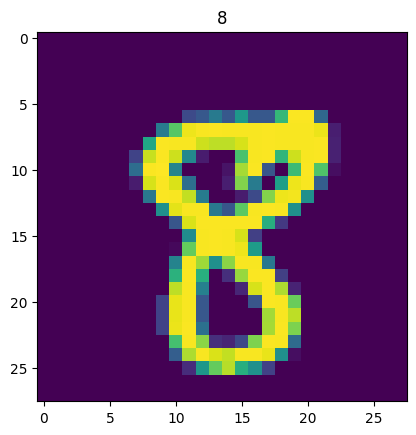

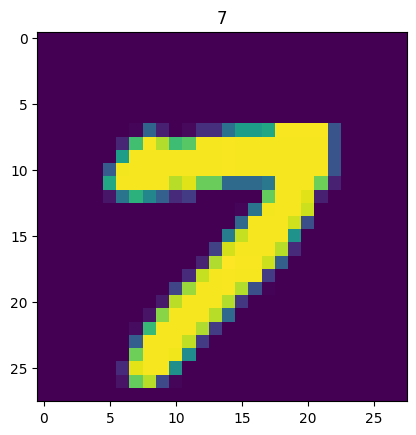

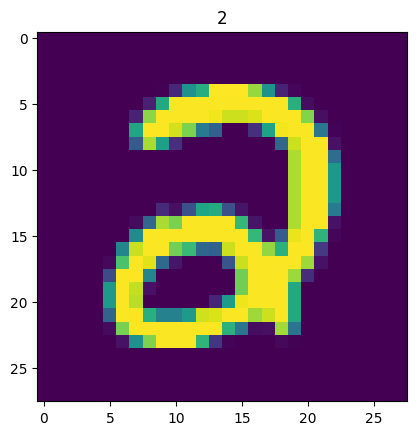

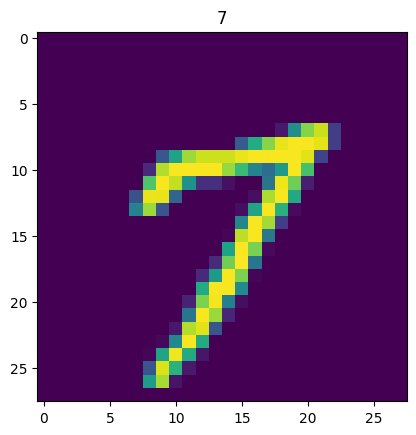

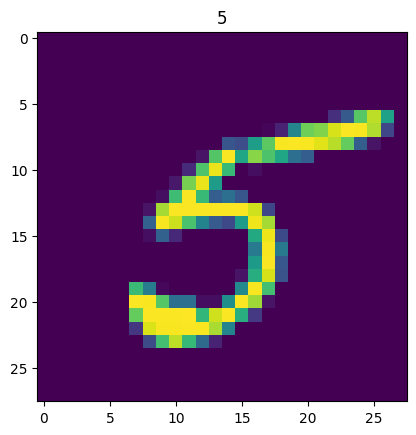

In [ ]:
data = MNIST(
    root="./root", # gives the path where we want to download the dataset
    train=True, 
    download=True, # we will download the dataset on the given address
    transform=transforms.ToTensor() # convert into a Tensor 
    # transforms only the image data into a Tensor - class labels remain as integers
)

extract_data = DataLoader(data, batch_size=100, shuffle=True)
count = 0
for img, ll in extract_data:
    if count == 5:
        break
    plt.imshow(img.squeeze())
    plt.title(ll.item())
    plt.show()

    count += 1

# print(training_data)




In [60]:
Data = Subset(data, range(6000))

In [ ]:
images = data.data
labels = data.targets

X_train, X_val, X_test = random_split(
    images,
    [3000,1500,1500]
)
y_train, y_val, y_test = random_split(
    labels,
    [3000,1500,1500]
)

In [65]:
train_data, val_data, test_data = random_split(
    Data,
    [3000,1500,1500]
)

In [74]:
class CNN_Pytorch(nn.Module):

    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(
            in_channels=1,
            out_channels=3,
            kernel_size=3
            )
        self.maxi = nn.MaxPool2d(kernel_size=2)
        self.relu = nn.ReLU()
        self.fin = nn.Linear(3*13*13, 10)
    
    def forward(self, X):
        X = self.conv(X)
        X = self.maxi(X)
        X = self.relu(X)
        X = X.flatten()
        X = self.fin(X)

        return X
    

model = CNN_Pytorch()
optimizer = optim.SGD(model.parameters(), lr=0.001)

In [76]:
model.train()
criterion = nn.CrossEntropyLoss()
losses = []
for epoch in range(10):
    # enumarate has two parameters i - iter and the object
    for x, y in train_data:
        y = torch.tensor(y)
        predict = model(x)
        optimizer.zero_grad() 
        model.forward(x)    
        loss = criterion(predict, y)
        loss.backward() # for backpropagation
        optimizer.step()
        losses.append(loss.item())
        if epoch % 100 == 0:
            print(loss.item())



0.30192995071411133
0.7035825848579407
0.15950866043567657
0.4074521064758301
0.5604020953178406
0.19220039248466492
0.3024389147758484
0.5116399526596069
0.3788728713989258
0.8782336115837097
0.37092211842536926
0.12451930344104767
0.1938486099243164
1.4656111001968384
0.8607551455497742
1.2047356367111206
0.5120744705200195
0.16498993337154388
1.2037451267242432
0.3968620002269745
0.5002515316009521
1.5702437162399292
2.53255033493042
0.18039102852344513
0.3926126956939697
1.9695041179656982
1.7697664499282837
0.15155427157878876
1.0495375394821167
0.6088934540748596
0.7804524898529053
0.22021807730197906
0.407370001077652
1.1560918092727661
0.5992736220359802
0.18869709968566895
1.1671500205993652
0.3342882990837097
1.3400537967681885
0.11801453679800034
2.050631523132324
0.6792818307876587
0.34304556250572205
0.6924129724502563
0.6272042393684387
0.915788471698761
0.2586861848831177
1.40133798122406
0.44459208846092224
0.09841857105493546
1.5413435697555542
2.3103649616241455
0.124

In [78]:
model.eval() # no computational graph -> no gradients calculations, param updates
with torch.no_grad():
    accuracy = 0
    count = 0.0
    for x, y in val_data:
        predict_label = torch.argmax(model(x))
        if predict_label == y:
            count += 1

    accuracy = count/len(val_data)

print(accuracy)


0.8926666666666667


In [79]:
model.eval() # no computational graph -> no gradients calculations, param updates
with torch.no_grad():
    accuracy = 0
    count = 0.0
    for x, y in test_data:
        predict_label = torch.argmax(model(x))
        if predict_label == y:
            count += 1

    accuracy = count/len(val_data)

print(accuracy)


0.8886666666666667


In [ ]:
# images = data[:,0,-1]
# labels = data[:, -1]

# train_mask = range(0, len(images)//2, 1)
# val_mask = range(len(images)//2 + 1, len(images)* 2//3, 1)
# test_mask = range(len(images)* 2//3 + 1, len(images), 1)

# X_train = images[train_mask]
# y_train = labels[train_mask]

# X_val = images[val_mask]
# y_val = labels[val_mask]


# X_test = images[test_mask]
# y_test = labels[test_mask]

